In [1]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
import yaml
import time
import pickle as pkl
import os
import numpy as np
from matplotlib import cm
from scipy.signal import welch,periodogram
import pandas as pd
import glob
from scipy.optimize import curve_fit
from scipy import signal

import pysmurf.client
import matplotlib.pylab as plt
import numpy as np
import sys
import os

# PCIe version

In [2]:
!cat /proc/datadev_0; cat /proc/datadev_1

PCIe[BUS:NUM:SLOT.FUNC] : 0000:3b:00.0
---------- Firmware Axi Version -----------
     Firmware Version : 0x4030000
           ScratchPad : 0x0
        Up Time Count : 645202
             Git Hash : e08cfef1df60c1df7477fc23043e87bdec0c8cdf
            DNA Value : 0x00000000400200010117f1801c512445
         Build String : SmurfKcu1500RssiOffload10GbE: Vivado v2023.1, rdsrv428 (Ubuntu 22.04.5 LTS), Built Wed Sep  3 03:49:46 PM PDT 2025 by ruckman

---------- DMA Firmware General ----------
          Int Req Count : 0
         Continue Count : 43088
          Address Count : 4096
    Hw Write Buff Count : 1024
     Hw Read Buff Count : 0
           Cache Config : 0x0
            Desc 128 En : 1
            Enable Ver  : 0x5010501
      Driver Load Count : 5
               IRQ Hold : 10000
              BG Enable : 0x0
           GPU Async En : 0
            DMA Timeout : 65535

-------- DMA Kernel Driver General --------
 DMA Driver's Git Version : 6.7.1
 DMA Driver's API Version : 0x6
 

# Get a control object

In [3]:
epics_prefix="smurf_server_s4"
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/b33/experiment_b33_rfc1-2_C05-40_s4_2xLB_extref.cfg")
S = pysmurf.client.SmurfControl(epics_root=epics_prefix,cfg_file=config_file,setup=False,make_logfile=False,shelf_manager="shm-smrf-sp01")

# Versions

What versions of everything are we running?

In [4]:
pysmurf.__version__

'8.1.0+2.g54942014'

In [16]:
S.get_rogue_version()

'v4.11.11'

In [14]:
S.get_fpga_git_hash_short()

'4daa68b'

In [15]:
S.C.get_fw_version()

(4, 0, 7)

What hardware are we using?  use_shell=True is slower but doesn't require the atca_monitor docker.

In [6]:
S.get_carrier_sn(use_shell=True)

'C03-A03-21'

In [7]:
S.get_rtm_sn(use_shell=True)

'C01-C01-A02-79'

In [13]:
for bay in S.bays:
    print(f'bay{bay} : {S.get_amc_sn(bay,use_shell=True)}')

bay0 : C03-A01-167
bay1 : C03-A01-169


# Timing setup

What timing mode are we in now?

In [17]:
print(S.get_timing_mode())

ext_ref


In [85]:
S.set_timing_mode('ext_ref')

[ 2026-02-21 06:15:38 ]  System configured for backplane timing.  Reconfiguring slot 4 for ext_ref timing.
[ 2026-02-21 06:15:38 ]  Select external reference for bay 0 or free running if there is no reference.
[ 2026-02-21 06:15:38 ]  Select external reference for bay 1 or free running if there is no reference.


In [86]:
S.get_downsample_mode()

'external'

In [87]:
S.set_downsample_mode('internal')

In [88]:
print(f'timing mode is {S.get_timing_mode()}')
print(f'downsample mode is {S.get_downsample_mode()}')

timing mode is ext_ref
downsample mode is internal


# Set some fixed tones

Right now, bay 1 is in loopback, so we'll put a few fixed tones on it.  Doing it randomly, for kicks.  Trying band 1.

In [38]:
band=4
ntones=3

In [40]:
import numpy as np
# stick in +/-200 MHz of band center to avoid edges.
fs=np.random.uniform(low=S.get_band_center_mhz(band)-200, high=S.get_band_center_mhz(band)+200, size=(3,)) 
for f in fs:
	print(f'f = {f:.3f} MHz')
	S.set_fixed_tone(f,12)

f = 6234.149 MHz
f = 6239.722 MHz
f = 6122.407 MHz


In [41]:
print(S.which_on(band))

[211 415 479]


Do we see tones?

[ 2026-02-21 06:15:54 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[1]:DataBufferSize 524288
[ 2026-02-21 06:15:54 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[1] 0


/usr/local/src/pysmurf/python/pysmurf/client/util/smurf_util.py:1765: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_fn)


[ 2026-02-21 06:15:56 ]  ADC plot saved to /data/smurf_data/20260221/1771652768/plots/1771654555_adc4.png
[ 2026-02-21 06:15:56 ]  Saving raw adc data to /data/smurf_data/20260221/1771652768/outputs/1771654555_adc4


array([  132.-1656.j,  -844.-3409.j, -2311.-3924.j, ...,   229.+1594.j,
        1751.+1414.j,  2353.-1583.j])

/usr/local/lib/python3.8/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


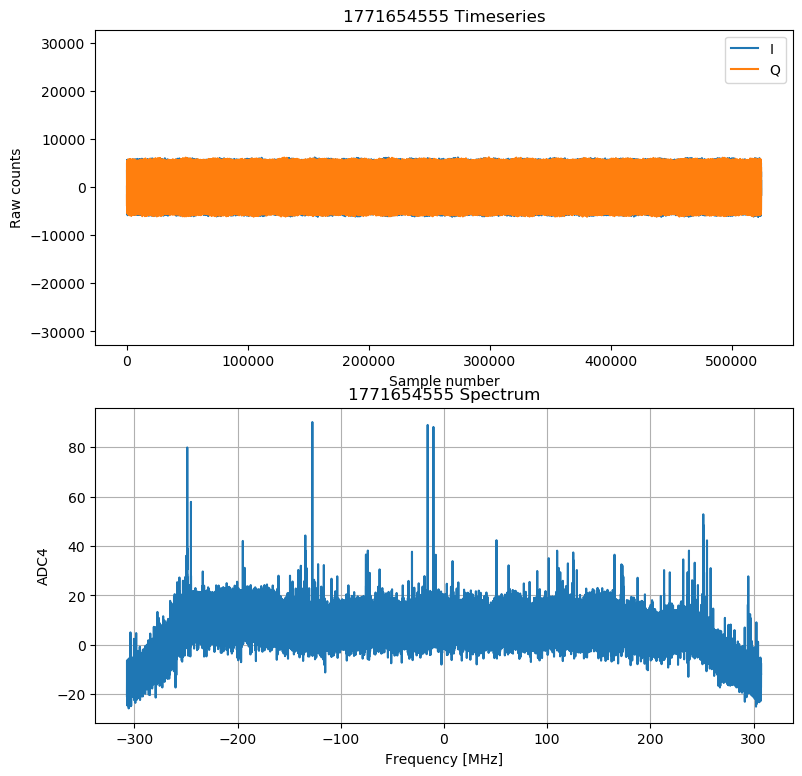

In [89]:
S.read_adc_data(band,make_plot=True,show_plot=True)

Tones are there!

# Debug data

Let's look at the raw DDC IQ data.  Because *reasons* we need some extra functions to decode the I/Q debug data right now.

In [43]:
def first_sublist_index(lst, sub):
    n, m = len(lst), len(sub)
    if m == 0:
        return 0
    for i in range(n - m + 1):
        if lst[i:i+m] == sub:
            return i
    return -1  # not found

def chdec_iq(S,i,q):
    chans = S.which_on(band)
    proc_chans=S.get_processed_channels(band)
    proc_chans = sorted([chan if chan != 22 else 25 for chan in proc_chans])
    chan_debug_indices=[proc_chans.index(chan) for chan in chans]
    
    #decode based on i for now
    nzi_idx=np.nonzero(i)[0]
    lst=list(np.diff(nzi_idx))
    sub=list(np.diff(chan_debug_indices))
    difftrimidx=first_sublist_index(lst, sub)

    dd={}
    chan_offsets=np.diff(chan_debug_indices)
    chan_offsets = np.insert(chan_offsets, 0, 0, axis=0)
    for ichan,chan in enumerate(chans):
        dd[chan]={}
        #print(f'{ichan} {nzi_idx[difftrimidx]+np.sum(chan_offsets[:ichan+1])}')
        dd[chan]['i']=i[nzi_idx[difftrimidx]+np.sum(chan_offsets[:ichan+1])::416]
        dd[chan]['q']=q[nzi_idx[difftrimidx]+np.sum(chan_offsets[:ichan+1])::416]
        #print(chan_offsets[:ichan])

    return dd

Take some I/Q samples and decode.

In [90]:
i,q,sync = S.take_debug_data(band=band,channel=None,rf_iq=True,nsamp=2**24)
dd=chdec_iq(S,i,q)

[ 2026-02-21 06:16:18 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:SysgenCryo:Base[4]:singleChannelReadout 0
[ 2026-02-21 06:16:18 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:SysgenCryo:Base[4]:singleChannelReadoutOpt2 0
[ 2026-02-21 06:16:18 ]  Writing to file : /data/smurf_data/20260221/1771652768/outputs/1771654578.dat
[ 2026-02-21 06:16:18 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[1]:DataBufferSize 16777216
[ 2026-02-21 06:16:18 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[1] 0
[ 2026-02-21 06:16:18 ]  Data acquisition in progress...
[ 2026-02-21 06:16:18 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[1]:TriggerDaq 1
[ 2026-02-21 06:16:20 ]  Done taking data


Decode data, for historical reasons, is scaled by a small factor that's only relevant for uMUX.  Need to descale.

In [45]:
n_subbands = S.get_number_sub_bands()
digitizer_frequency_mhz = S.get_digitizer_frequency_mhz()
subband_half_width_mhz = (digitizer_frequency_mhz / n_subbands)

descale_factor = 2**23/subband_half_width_mhz
print(f'descale_factor = {descale_factor}')

descale_factor = 6990506.666666667


Text(0, 0.5, 'I [ADC counts?]')

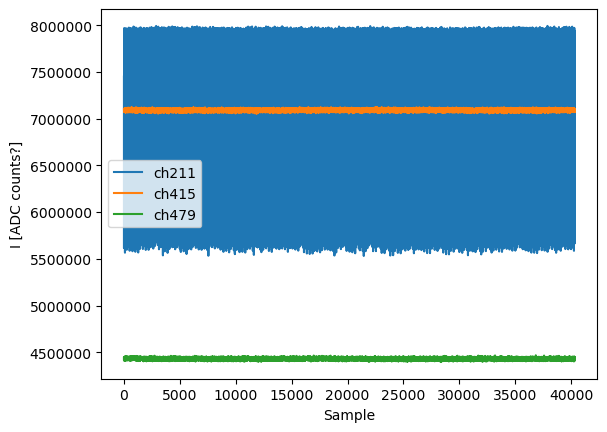

In [91]:
for ch in dd.keys():
    plt.plot(descale_factor*dd[ch]['i'],label=f'ch{ch}')

plt.legend()
plt.xlabel('Sample')
plt.ylabel('I [ADC counts?]')

Not sure what's up with ch211.  Did we descale properly?  Should have integers.

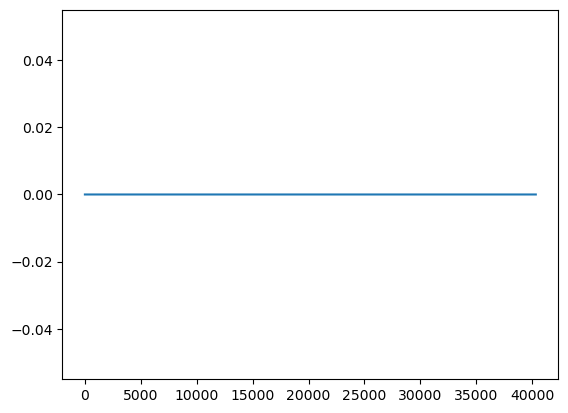

In [92]:
plt.plot(descale_factor*dd[ch]['i'] - np.array(np.round(descale_factor*dd[ch]['i'])))

I think? that worked.  Ok, streaming time.

# Streaming data

What streaming mode, if any, are we in now?

In [93]:
print(f"baySelStream: {S._caget(f'{S.app_core}baySelStream')}")
print(f"modeStream: {S._caget(f'{S.app_core}modeStream')}")

baySelStream: 1
modeStream: 1


Need to select correct baySelStream.

In [94]:
S._caput(f'{S.app_core}baySelStream', int(band/4), write_log=True)
S._caput(f'{S.app_core}modeStream', 1,write_log=True)
print(f"baySelStream: {S._caget(f'{S.app_core}baySelStream',write_log=True)}")
print(f"modeStream: {S._caget(f'{S.app_core}modeStream',write_log=True)}")

[ 2026-02-21 06:16:39 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream 1
[ 2026-02-21 06:16:39 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream 1
[ 2026-02-21 06:16:39 ]  caget smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream
[ 2026-02-21 06:16:39 ]  1
baySelStream: 1
[ 2026-02-21 06:16:39 ]  caget smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream
[ 2026-02-21 06:16:39 ]  1
modeStream: 1


In [95]:
# Sample rate (can't go above 38ish)
S.flux_ramp_setup(30.0,0)

[ 2026-02-21 06:16:41 ]  Percent full scale = 0.000%


Disable filter and downsample.

In [96]:
# Configure filter / downsample
S.set_filter_disable(True)
S.set_downsample_factor(1)

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

S.get_sample_frequency()=30000.0
S.get_downsample_factor()=1
S.get_filter_disable()=1


Ok, so what I'm going to do is try to both stream data the usual way, and also open a raw file using the GUI directly, via the `streamingInterface` System option.

In [98]:
# loss counter tells you if you lost any frames btw rfsoc and pcie card.  
# Very unlikely at these channel counts, but good to check.
loss0 = S.get_frame_loss_cnt()
fname = S.take_stream_data(30,IQ_mode=True) # also dump a short full stream during this - use the `streamingInterface`
loss1 = S.get_frame_loss_cnt()

print(f'Frames lost = {loss1-loss0} should be zero.')

[ 2026-02-21 06:17:38 ]  Starting to take data.
[ 2026-02-21 06:17:38 ]  Input downsample factor is None. Using value already in pyrogue: 1
[ 2026-02-21 06:17:38 ]  Flux ramp is AC-coupled.
[ 2026-02-21 06:17:42 ]  caput smurf_server_s4:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-02-21 06:17:42 ]  caput smurf_server_s4:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-02-21 06:17:42 ]  Writing to file : /data/smurf_data/20260221/1771652768/outputs/1771654662.dat
[ 2026-02-21 06:17:42 ]  /data/smurf_data/20260221/1771652768/outputs/1771654662_mask.txt
[ 2026-02-21 06:17:42 ]  Writing frequency mask.
[ 2026-02-21 06:17:42 ]  caput smurf_server_s4:AMCc:SmurfProcessor:FileWriter:Open 1
[ 2026-02-21 06:18:12 ]  caput smurf_server_s4:AMCc:SmurfProcessor:FileWriter:Close 1
[ 2026-02-21 06:18:12 ]  caput smurf_server_s4:AMCc:FpgaTopLevel:AppTop:AppCore:enableStreaming 0
[ 2026-02-21 06:18:12 ]  Waiting 0.15 seconds after...
[ 2026-02-21 06:18:12 ]  Done waiting.
[ 2026-02-21 06:18:12 ]  Done taking d

The raw file I opened was /data/data_20260221_061742.dat and I had it open for maybe 5 sec.

Did both files get written?

In [100]:
! du -shc /data/data_20260221_061742.dat 

1.2G	/data/data_20260221_061742.dat
1.2G	total


In [99]:
!du -shc /data/smurf_data/20260221/1771652768/outputs/1771654662.dat

138M	/data/smurf_data/20260221/1771652768/outputs/1771654662.dat
138M	total


Oops, that's an absurd amount of data.

Reading the stream data;

In [101]:
t,d,m = S.read_stream_data(fname,IQ_mode=True)

[ 2026-02-21 06:19:00 ]  Reading /data/smurf_data/20260221/1771652768/outputs/1771654662.dat
Processing data records from /data/smurf_data/20260221/1771652768/outputs/1771654662.dat
[ 2026-02-21 06:19:00 ]  2048 elements loaded
[ 2026-02-21 06:19:00 ]  4096 elements loaded
[ 2026-02-21 06:19:00 ]  6144 elements loaded
[ 2026-02-21 06:19:00 ]  8192 elements loaded
[ 2026-02-21 06:19:00 ]  10240 elements loaded
[ 2026-02-21 06:19:00 ]  12288 elements loaded
[ 2026-02-21 06:19:00 ]  14336 elements loaded
[ 2026-02-21 06:19:00 ]  16384 elements loaded
[ 2026-02-21 06:19:01 ]  18432 elements loaded
[ 2026-02-21 06:19:01 ]  20480 elements loaded
[ 2026-02-21 06:19:01 ]  22528 elements loaded
[ 2026-02-21 06:19:01 ]  24576 elements loaded
[ 2026-02-21 06:19:01 ]  26624 elements loaded
[ 2026-02-21 06:19:01 ]  28672 elements loaded
[ 2026-02-21 06:19:01 ]  30720 elements loaded
[ 2026-02-21 06:19:01 ]  32768 elements loaded
[ 2026-02-21 06:19:01 ]  34816 elements loaded
[ 2026-02-21 06:19:01 ]

In [102]:
print(d.shape)

(3, 901248)


Great.  What's it look like?

/usr/local/lib/python3.8/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


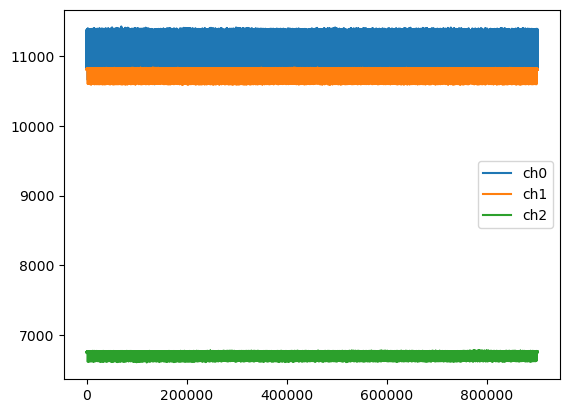

In [103]:
for ch in range(len(d)):
    plt.plot(d[ch].real,label=f'ch{ch}')

plt.legend()

Ok.  Good news and bad news.  Good news is it's not totally disimilar from the I/Q data.  What's it look like on shorter sample scales?

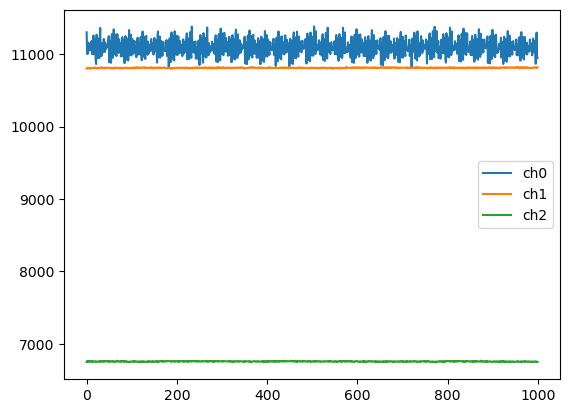

In [104]:
for ch in range(len(d)):
    plt.plot(d[ch].real[0:1000],label=f'ch{ch}')

plt.legend()

Interesting.  What does just one look like.

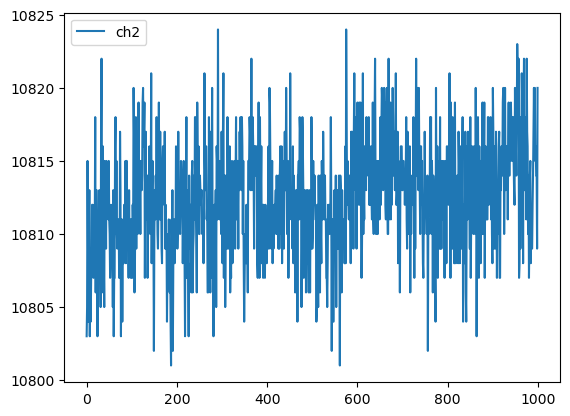

In [105]:
plt.plot(d[1].real[0:1000],label=f'ch{ch}')

plt.legend()

Shockingly, that looks like actual data, but the scale doesn't make sense.  Does `read_stream_data` apply any scaling?

In [106]:
S.read_stream_data??

Signature:
S.read_stream_data(
    datafile,
    channel=None,
    nsamp=None,
    array_size=None,
    return_header=False,
    return_tes_bias=False,
    write_log=True,
    n_max=2048,
    make_freq_mask=False,
    gcp_mode=False,
    IQ_mode=True,
)
Source:   
    @set_action()
    def read_stream_data(self, datafile, channel=None,
                         nsamp=None, array_size=None,
                         return_header=False,
                         return_tes_bias=False, write_log=True,
                         n_max=2048, make_freq_mask=False,
                         gcp_mode=False, IQ_mode=True):
        """
        Loads data taken with the function stream_data_on.
        Gives back the resonator data in units of phase. Also
        can optionally return the header (which has things
        like the TES bias).

        Args
        ----
        datafile : str
            The full path to the data to read.
        channel : int or int array or None, optional, default None

Looks like no.

Need to find the relation between the streaming data and the debug data.


In [148]:
print(dd[479]['i'][:10]*descale_factor)

[4438842. 4432886. 4436959. 4417533. 4413560. 4434987. 4435102. 4420783.
 4436906. 4445993.]


In [151]:
print(dd[479]['q'][:10]*descale_factor)

[6575305. 6607210. 6602342. 6597596. 6614049. 6606254. 6600311. 6588742.
 6597470. 6595658.]


In [150]:
print(d[2][:10])

[6750.+10052.j 6761.+10055.j 6752.+10055.j 6759.+10059.j 6754.+10059.j
 6758.+10055.j 6754.+10053.j 6761.+10061.j 6755.+10054.j 6749.+10052.j]
